In [1]:
# =========================
#  (imports + config + load data)
# =========================

import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE


import lightgbm as lgb
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")


# ---- Reproducibility ----
SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False



# ---- ST004145 columns (match your CSV header; 12 features incl. DHEA) ----
hormone_columns = [
    "11-Dehydrocorticosterone_POS",
    "11-deoxycortisol_POS",
    "11-ketotestosterone_POS",
    "17a-OH-progesterone_POS",
    "Androstenedione_POS",
    "Corticosterone_POS",
    "Cortisol_POS",
    "Cortisone_POS",
    "Estradiol_POS",
    "Pregnenolone_POS",
    "Testosterone_POS",
    "DHEA-sulfate_NEG",
]

# If your notebook runs in a different working directory, you can also set:
# DATA_PATH = r"/mnt/data/ST004145_MERGED_log10_clean.csv"
#DATA_PATH = "ST004145_MERGED_log10_clean.csv"

import os

DATA_DIR = "/content"

def resolve_data_path(filename: str) -> str:
    p = os.path.join(DATA_DIR, filename)
    if os.path.exists(p):
        return p
    if os.path.exists(filename):
        return filename
    raise FileNotFoundError(
        f"Cannot find {filename}\n"
        f"Expected at: {p}\n"
        f"/content contents: {os.listdir('/content')}\n"
        f"CWD: {os.getcwd()}"
    )

if os.path.exists("/content/ST004145_MERGED_log10_clean.csv"):
    DATA_PATH = resolve_data_path("ST004145_MERGED_log10_clean.csv")
else:
    DATA_PATH = resolve_data_path("ST000355_MERGED_log10_MinImputed.csv")

print("Using DATA_PATH =", DATA_PATH)


def load_st004145(path=DATA_PATH):
    df = pd.read_csv(path)

    missing = [c for c in hormone_columns if c not in df.columns]
    if missing:
        raise ValueError(f"Missing hormone columns in CSV: {missing}")

    if "Factor_Group" not in df.columns:
        raise ValueError("Missing 'Factor_Group' column in CSV.")

    X = df[hormone_columns].copy()

    # Factor_Group: control=0, case=1
    fg = df["Factor_Group"]
    if fg.dtype == object:
        fg_norm = fg.astype(str).str.strip().str.lower()
        y = fg_norm.map({"control": 0, "case": 1})
    else:
        y = fg

    if pd.isna(y).any():
        bad = df.loc[pd.isna(y), "Factor_Group"].unique()
        raise ValueError(f"Unmapped Factor_Group values: {bad}. Expected only control/case.")

    y = y.astype(int)
    return X, y


def load_dataset(path=DATA_PATH):
    """Load either ST004145 or ST000355 with correct label mapping.

    - ST004145: label column Factor_Group (control/case); features are hormone_columns
    - ST000355: label column Factor_Diagnosis (Control/Breast cancer); features are all columns except label
    """
    df = pd.read_csv(path)

    # ST000355
    if "Factor_Diagnosis" in df.columns:
        label_col = "Factor_Diagnosis"
        X = df.drop(columns=[label_col]).copy()
        s = df[label_col].astype(str).str.strip().str.lower()
        y = s.map({"control": 0, "breast cancer": 1})
        if y.isna().any():
            bad = df.loc[y.isna(), label_col].unique()
            raise ValueError(f"Unmapped {label_col} values: {bad}")
        return X, y.astype(int)

    # ST004145
    if "Factor_Group" in df.columns:
        # reuse the original ST004145 loader to keep behavior identical
        return load_st004145(path)

    raise ValueError(
        "Unknown dataset format: expected label column 'Factor_Diagnosis' (ST000355) "
        "or 'Factor_Group' (ST004145)."
    )


Using DATA_PATH = /content/ST000355_MERGED_log10_MinImputed.csv


In [2]:
# =========================
#  (definitions; leak-free; 5-fold CV for all)
# =========================

class SteroidHormoneProcessor:
    """
    Leak-free preprocessing:
    - Fit ONLY on the TRAIN fold
    - Then transform VAL fold using training-fitted params
    """
    def __init__(self, scaler_kind='robust'):
        self.scaler = None
        self.selected_features = None
        self._medians = None
        self._clip_q1 = None
        self._clip_q99 = None
        self._log_cols = None
        self.scaler_kind = str(scaler_kind).lower()

    def _decide_log_cols(self, X):
        log_cols = []
        for col in X.columns:
            if X[col].min() > 0 and X[col].skew() > 1:
                log_cols.append(col)
        return log_cols

    def fit(self, X):
        Xp = X.copy().replace([np.inf, -np.inf], np.nan)

        # training medians only
        self._medians = Xp.median(numeric_only=True)
        Xp = Xp.fillna(self._medians)

        # decide log cols based on training only
        self._log_cols = self._decide_log_cols(Xp)

        # apply log for deciding clipping + scaler fit
        Xp2 = Xp.copy()
        for c in self._log_cols:
            Xp2[c] = np.log1p(Xp2[c])

        # training clipping thresholds only
        self._clip_q1, self._clip_q99 = {}, {}
        for col in Xp2.columns:
            self._clip_q1[col] = float(Xp2[col].quantile(0.01))
            self._clip_q99[col] = float(Xp2[col].quantile(0.99))

        # training scaler only
        if self.scaler_kind == 'standard':
            self.scaler = StandardScaler()
        else:
            self.scaler = RobustScaler(quantile_range=(5, 95))
        self.scaler.fit(Xp2.values)

        self.selected_features = X.columns.tolist()
        return self

    def transform(self, X):
        if self.scaler is None:
            raise RuntimeError("Processor not fitted. Call fit() on training data first.")

        Xp = X.copy().replace([np.inf, -np.inf], np.nan)
        Xp = Xp.fillna(self._medians)

        # apply the same log decision from training
        for c in self._log_cols:
            if c in Xp.columns:
                Xp[c] = np.log1p(Xp[c])

        # clip using training thresholds
        for col in Xp.columns:
            Xp[col] = Xp[col].clip(self._clip_q1[col], self._clip_q99[col])

        X_scaled = self.scaler.transform(Xp.values)
        return pd.DataFrame(X_scaled, columns=self.selected_features, index=Xp.index)

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class DifficultyScorer:
    def __init__(self):
        self.centroids = None
        self.simple_model = None
        self.iso_forest = None

    def fit(self, X, y):
        Xv = X.values if isinstance(X, pd.DataFrame) else X
        yv = y.values if hasattr(y, "values") else y

        self.centroids = {}
        for cls in np.unique(yv):
            mask = yv == cls
            self.centroids[cls] = np.mean(Xv[mask], axis=0)

        self.simple_model = RandomForestClassifier(n_estimators=30, max_depth=2, random_state=SEED)
        self.simple_model.fit(Xv, yv)

        self.iso_forest = IsolationForest(contamination=0.1, random_state=SEED)
        self.iso_forest.fit(Xv)
        return self

    def score_difficulty(self, X):
        Xv = X.values if isinstance(X, pd.DataFrame) else X
        n = len(Xv)

        dist = np.zeros(n)
        conf = np.zeros(n)
        outl = np.zeros(n)

        if self.centroids:
            for i, x in enumerate(Xv):
                md = float("inf")
                for _, c in self.centroids.items():
                    md = min(md, np.linalg.norm(x - c))
                dist[i] = md
        if dist.max() > 0:
            dist = dist / dist.max()

        if self.simple_model:
            prob = self.simple_model.predict_proba(Xv)
            conf = 1 - np.max(prob, axis=1)

        if self.iso_forest:
            lab = self.iso_forest.predict(Xv)
            outl = (lab == -1).astype(float)

        return (dist + conf + outl) / 3


class CurriculumTrainer:
    def __init__(self, model, curriculum_stages=3, stage_epochs=None):
        self.model = model
        self.curriculum_stages = curriculum_stages
        self.stage_epochs = stage_epochs
        self.difficulty_scorer = DifficultyScorer()
        self.difficulty_scores = None

    def _subset(self, X, y, stage):
        n = len(X)
        frac = 0.3 + 0.7 * (stage / (self.curriculum_stages - 1))
        m = max(1, int(n * frac))

        idx = np.argsort(self.difficulty_scores)[:m]
        Xs = X.iloc[idx] if isinstance(X, pd.DataFrame) else X[idx]
        ys = y.iloc[idx] if isinstance(y, pd.Series) else y[idx]
        return Xs, ys

    def fit_with_curriculum(self, X, y, verbose=False):
        self.difficulty_scorer.fit(X, y)
        self.difficulty_scores = self.difficulty_scorer.score_difficulty(X)

        if self.stage_epochs is None:
            total_epochs = min(100, max(20, len(X) // 10))
            self.stage_epochs = max(1, total_epochs // self.curriculum_stages)

        for stage in range(self.curriculum_stages):
            Xs, ys = self._subset(X, y, stage)

            if hasattr(self.model, "partial_fit"):
                classes = np.unique(y)
                for _ in range(self.stage_epochs):
                    self.model.partial_fit(Xs, ys, classes=classes)
            else:
                if hasattr(self.model, "warm_start") and hasattr(self.model, "n_estimators"):
                    if stage == 0:
                        self.model.fit(Xs, ys)
                    else:
                        cur = self.model.n_estimators
                        self.model.set_params(n_estimators=cur + self.stage_epochs)
                        self.model.fit(Xs, ys)
                else:
                    self.model.fit(Xs, ys)

        return self.model

import re

def sanitize_columns(cols):
    """Return LightGBM-safe, unique column names (deterministic)."""
    cols = [str(c) for c in cols]
    cleaned = []
    for c in cols:
        c2 = c
        c2 = c2.replace("\\", "_").replace('"', "_")
        c2 = c2.replace("\n", "_").replace("\r", "_").replace("\t", "_")
        c2 = re.sub(r"[^0-9a-zA-Z_]+", "_", c2).strip("_")
        if c2 == "":
            c2 = "f"
        cleaned.append(c2)

    # make unique
    seen = {}
    uniq = []
    for c in cleaned:
        if c not in seen:
            seen[c] = 0
            uniq.append(c)
        else:
            seen[c] += 1
            uniq.append(f"{c}__{seen[c]}")
    return uniq


def save_oof_outputs(model_name, y_true, y_prob, out_dir="oof_outputs", threshold=0.5):
    """
    Save out-of-fold predictions for downstream ROC, confusion matrix,
    and metric-table generation.
    """
    import os
    from sklearn.metrics import (
        roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
    )

    os.makedirs(out_dir, exist_ok=True)

    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    np.save(os.path.join(out_dir, f"{model_name}_y_true.npy"), y_true)
    np.save(os.path.join(out_dir, f"{model_name}_y_prob.npy"), y_prob)
    np.save(os.path.join(out_dir, f"{model_name}_y_pred.npy"), y_pred)

    oof_df = pd.DataFrame({
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
    })
    oof_df.to_csv(os.path.join(out_dir, f"{model_name}_oof_predictions.csv"), index=False)

    metrics = {
        "Model": model_name,
        "AUC": float(roc_auc_score(y_true, y_prob)),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
    }
    pd.DataFrame([metrics]).to_csv(
        os.path.join(out_dir, f"{model_name}_metrics.csv"),
        index=False
    )

    return metrics






def train_baselines_cv(
    X, y,
    use_curriculum=True,
    curriculum_stages=3,
    n_splits=5,
    sampling=None,
    save_oof_for=None,
    out_dir="oof_outputs"
):
    """
    Leak-free 5-fold CV: processor.fit_transform on TRAIN fold only.
    Optionally save out-of-fold predictions for selected baseline models.
    """
    print(f"\n Baselines (Curriculum: {use_curriculum}) | {n_splits}-fold CV")

    if save_oof_for is None:
        save_oof_for = []

    models = {
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.03,
            random_state=SEED, verbosity=-1, warm_start=True
        ),
        "LR": LogisticRegression(C=0.1, max_iter=1000, random_state=SEED),
        "SVM": SVC(kernel="rbf", probability=True, random_state=SEED),
    }

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    out = {}

    for name, model in models.items():
        scores = []
        oof_y_true = []
        oof_y_prob = []

        for tr, va in skf.split(X, y):
            Xtr_raw, Xva_raw = X.iloc[tr], X.iloc[va]
            ytr, yva = y.iloc[tr], y.iloc[va]

            # sampling (TRAIN fold only) to avoid leakage
            Xtr_raw_s, ytr_s = apply_sampling_train_fold_df(
                Xtr_raw, ytr, sampling=sampling, random_state=SEED
            )

            processor = SteroidHormoneProcessor()
            Xtr = processor.fit_transform(Xtr_raw_s)
            Xva = processor.transform(Xva_raw)

            # ---- LightGBM-safe feature names (fix JSON special char error) ----
            safe_cols = sanitize_columns(Xtr.columns)
            Xtr = Xtr.copy(); Xtr.columns = safe_cols
            Xva = Xva.copy(); Xva.columns = safe_cols

            if use_curriculum:
                trainer = CurriculumTrainer(
                    model.__class__(**model.get_params()),
                    curriculum_stages=curriculum_stages
                )
                clf = trainer.fit_with_curriculum(Xtr, ytr_s, verbose=False)
            else:
                clf = model.__class__(**model.get_params())
                clf.fit(Xtr, ytr_s)

            p = clf.predict_proba(Xva)[:, 1]
            scores.append(roc_auc_score(yva, p))

            full_model_name = f"Baseline_{name}_{'Curriculum' if use_curriculum else 'Standard'}"
            if full_model_name in save_oof_for:
                oof_y_true.extend(np.asarray(yva).astype(int).tolist())
                oof_y_prob.extend(np.asarray(p).astype(float).tolist())

        out[name] = {"mean_auc": float(np.mean(scores)), "std_auc": float(np.std(scores))}
        tag = "curriculum" if use_curriculum else "standard"
        print(f"    {name} ({tag}): {out[name]['mean_auc']:.4f} ± {out[name]['std_auc']:.4f}")

        full_model_name = f"Baseline_{name}_{'Curriculum' if use_curriculum else 'Standard'}"
        if full_model_name in save_oof_for and len(oof_y_true) > 0:
            metrics = save_oof_outputs(
                model_name=full_model_name,
                y_true=np.array(oof_y_true),
                y_prob=np.array(oof_y_prob),
                out_dir=out_dir
            )
            out[name]["oof_auc"] = metrics["AUC"]
            out[name]["oof_accuracy"] = metrics["Accuracy"]
            out[name]["oof_precision"] = metrics["Precision"]
            out[name]["oof_recall"] = metrics["Recall"]
            out[name]["oof_f1"] = metrics["F1"]

    return out


# =========================
#  Sampling helpers (SMOTE / simple cGAN) - TRAIN FOLD ONLY
#  Strictly avoid leakage: fit/generate ONLY on Xtr within each CV fold.
# =========================



def _safe_smote_df(Xtr_df, ytr, random_state=SEED):
    y_arr = np.asarray(ytr)
    n_min = int((y_arr == 1).sum())
    n_maj = int((y_arr == 0).sum())
    if n_min == 0 or n_maj == 0:
        return Xtr_df, ytr

    k = max(1, min(5, n_min - 1))
    if k <= 0:
        return Xtr_df, ytr

    sm = SMOTE(random_state=random_state, k_neighbors=k)
    X_res, y_res = sm.fit_resample(Xtr_df.values, y_arr)
    X_res = pd.DataFrame(X_res, columns=Xtr_df.columns)
    y_res = pd.Series(y_res)
    return X_res, y_res


class _TabularCGAN(nn.Module):
    def __init__(self, x_dim, z_dim=16, hidden=64):
        super().__init__()
        self.z_dim = z_dim
        self.gen = nn.Sequential(
            nn.Linear(z_dim + 1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, x_dim),
        )
        self.disc = nn.Sequential(
            nn.Linear(x_dim + 1, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, 1),
            nn.Sigmoid(),
        )

    def g(self, z, y):
        return self.gen(torch.cat([z, y], dim=1))

    def d(self, x, y):
        return self.disc(torch.cat([x, y], dim=1))


def _cgan_augment_minority_df(
    Xtr_df, ytr,
    random_state=SEED,
    epochs=250,
    batch_size=32,
    z_dim=16,
    target_ratio=1.0,
    lr_g=2e-4,
    lr_d=2e-4,
):
    rng = np.random.RandomState(random_state)
    X = np.asarray(Xtr_df.values, dtype=np.float32)
    y = np.asarray(ytr, dtype=np.int64)

    n_min = int((y == 1).sum())
    n_maj = int((y == 0).sum())
    if n_min == 0 or n_maj == 0 or n_min >= n_maj:
        return Xtr_df, pd.Series(y)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    gan = _TabularCGAN(x_dim=X.shape[1], z_dim=z_dim).to(device)

    X_t = torch.tensor(X, device=device)
    y_t = torch.tensor(y.reshape(-1, 1).astype(np.float32), device=device)

    opt_g = optim.Adam(gan.gen.parameters(), lr=float(lr_g))
    opt_d = optim.Adam(gan.disc.parameters(), lr=float(lr_d))
    bce = nn.BCELoss()

    idx = np.arange(len(X))
    for _ in range(epochs):
        rng.shuffle(idx)
        for s in range(0, len(X), batch_size):
            b = idx[s:s + batch_size]
            xb = X_t[b]
            yb = y_t[b]

            # D
            z = torch.randn(len(b), z_dim, device=device)
            fake = gan.g(z, yb).detach()
            real_pred = gan.d(xb, yb)
            fake_pred = gan.d(fake, yb)
            d_loss = (bce(real_pred, torch.ones_like(real_pred)) +
                      bce(fake_pred, torch.zeros_like(fake_pred))) / 2
            opt_d.zero_grad()
            d_loss.backward()
            opt_d.step()

            # G
            z = torch.randn(len(b), z_dim, device=device)
            gen = gan.g(z, yb)
            pred = gan.d(gen, yb)
            g_loss = bce(pred, torch.ones_like(pred))
            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

    target_ratio = float(target_ratio)
    if target_ratio <= 0:
        return Xtr_df, pd.Series(y)

    target_min = int(np.ceil(target_ratio * n_maj))
    need = max(0, target_min - n_min)
    if need == 0:
        return Xtr_df, pd.Series(y)
    y_gen = np.ones((need, 1), dtype=np.float32)
    z = torch.randn(need, z_dim, device=device)
    with torch.no_grad():
        x_syn = gan.g(z, torch.tensor(y_gen, device=device)).cpu().numpy()

    X_aug = np.vstack([X, x_syn])
    y_aug = np.concatenate([y, np.ones(need, dtype=np.int64)])

    X_aug = pd.DataFrame(X_aug, columns=Xtr_df.columns)
    y_aug = pd.Series(y_aug)
    return X_aug, y_aug


def apply_sampling_train_fold_df(Xtr_df, ytr, sampling=None, random_state=SEED, sampling_params=None):
    if sampling is None:
        return Xtr_df, ytr
    s = str(sampling).strip().lower()
    if s == "smote":
        return _safe_smote_df(Xtr_df, ytr, random_state=random_state)
    if s == "gan":
        p = sampling_params or {}
        return _cgan_augment_minority_df(
            Xtr_df, ytr,
            random_state=random_state,
            epochs=p.get('gan_epochs', 250),
            batch_size=p.get('gan_batch_size', 32),
            z_dim=p.get('gan_z_dim', 16),
            target_ratio=p.get('gan_target_ratio', 1.0),
            lr_g=p.get('gan_lr_g', 2e-4),
            lr_d=p.get('gan_lr_d', 2e-4),
        )
    raise ValueError(f"Unknown sampling method: {sampling}")

# --------------------------
# Transformer + LGB Hybrid
# --------------------------

class HormonePathwayTransformer(nn.Module):
    def __init__(self, input_dim, embedding_dim=8, num_heads=2, num_layers=1, dropout=0.3):
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.pos_encoder = nn.Parameter(torch.randn(1, 1, embedding_dim) * 0.01)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=embedding_dim * 2,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers, enable_nested_tensor=False)

        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(embedding_dim, 2)
        )

    def forward(self, x):
        x = self.input_projection(x)
        x = x.unsqueeze(1) + self.pos_encoder
        x = self.transformer(x).squeeze(1)
        emb = x
        logits = self.classifier(x)
        return emb, logits

    def encode(self, x):
        self.eval()
        with torch.no_grad():
            x = self.input_projection(x)
            x = x.unsqueeze(1) + self.pos_encoder
            x = self.transformer(x).squeeze(1)
        return x.cpu().numpy()


class TransformerCurriculumTrainer:
    """
    IMPORTANT: works on *already preprocessed* data for that fold (no internal fit_transform).
    """
    def __init__(self, transformer, curriculum_stages=3, device=None):
        self.transformer = transformer
        self.curriculum_stages = curriculum_stages
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.difficulty_scorer = DifficultyScorer()

    def train_on_preprocessed(self, X_proc_df, y, epochs=30, batch_size=8, lr=0.0005):
        Xp = X_proc_df
        self.difficulty_scorer.fit(Xp, y)
        diff = self.difficulty_scorer.score_difficulty(Xp)
        sorted_idx = np.argsort(diff)

        X_tensor = torch.FloatTensor(Xp.values).to(self.device)
        y_tensor = torch.LongTensor(y.values).to(self.device)

        optimizer = optim.AdamW(self.transformer.parameters(), lr=lr, weight_decay=0.1)
        criterion = nn.CrossEntropyLoss()

        epochs_per_stage = max(1, epochs // self.curriculum_stages)

        for stage in range(self.curriculum_stages):
            frac = 0.3 + 0.7 * (stage / (self.curriculum_stages - 1))
            n = max(1, int(len(sorted_idx) * frac))
            stage_idx = sorted_idx[:n]

            ds = TensorDataset(X_tensor[stage_idx], y_tensor[stage_idx])
            dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

            for _ in range(epochs_per_stage):
                self.transformer.train()
                for bx, by in dl:
                    optimizer.zero_grad()
                    _, logits = self.transformer(bx)
                    loss = criterion(logits, by)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.transformer.parameters(), 0.5)
                    optimizer.step()

        return self.transformer


class SteroidHormoneHybridTransformerLGB:
    """
    Each fold has its own processor fitted on TRAIN only; used consistently.
    """
    def __init__(self, use_curriculum=True, curriculum_stages=3, device=None):
        self.use_curriculum = use_curriculum
        self.curriculum_stages = curriculum_stages
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        pp = processor_params or {}
        self.processor = SteroidHormoneProcessor(**pp)
        self.transformer = None
        self.lgb_model = None

    def fit(self, X_train_raw, y_train):
        X_train_proc = self.processor.fit_transform(X_train_raw)

        if self.use_curriculum:
            trainer = TransformerCurriculumTrainer(
                self.transformer, curriculum_stages=self.curriculum_stages, device=self.device
            )
            trainer.train_on_preprocessed(
                X_train_proc, y_train, epochs=30, batch_size=min(8, max(2, len(X_train_proc)//2))
            )
        else:
            Xt = torch.FloatTensor(X_train_proc.values).to(self.device)
            yt = torch.LongTensor(y_train.values).to(self.device)
            ds = TensorDataset(Xt, yt)
            dl = DataLoader(ds, batch_size=min(8, max(2, len(X_train_proc)//2)), shuffle=True, drop_last=True)

            optimizer = optim.AdamW(self.transformer.parameters(), lr=0.0005, weight_decay=0.1)
            criterion = nn.CrossEntropyLoss()

            for _ in range(30):
                self.transformer.train()
                for bx, by in dl:
                    optimizer.zero_grad()
                    _, logits = self.transformer(bx)
                    loss = criterion(logits, by)
                    loss.backward()
                    optimizer.step()

        # train LGB on train embeddings
        emb_train = self.extract_embeddings(X_train_raw)
        self.lgb_model = lgb.LGBMClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.03,
            random_state=SEED, verbosity=-1
        )
        self.lgb_model.fit(emb_train, y_train)
        return self

    def extract_embeddings(self, X_raw):
        X_proc = self.processor.transform(X_raw)
        Xt = torch.FloatTensor(X_proc.values).to(self.device)
        emb = self.transformer.encode(Xt)
        cols = [f"embedding_{i}" for i in range(emb.shape[1])]
        return pd.DataFrame(emb, columns=cols, index=X_raw.index)

    def predict_proba(self, X_raw):
        emb = self.extract_embeddings(X_raw)
        return self.lgb_model.predict_proba(emb)



# =========================
#  HYBRID variants (Transformer + different heads)
# =========================

def _infer_linear_in_features(model):
    # Try to infer the first Linear layer in_features safely
    for m in model.modules():
        if isinstance(m, nn.Linear):
            return m.in_features
    return None


def _fit_processor_and_transformer(processor, transformer, X_train_raw, y_train,
                                  use_curriculum=True, curriculum_stages=3, device=None,
                                  epochs=30, batch_size_cap=8, lr=0.0005):
    """
    Leak-free: processor.fit + transformer training are done ONLY on TRAIN fold.
    Now supports dynamic input_dim (e.g., 12 for ST004145, 227 for ST000355).
    Returns: (X_train_proc, transformer)
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # 1) fit processor on TRAIN fold only
    X_train_proc = processor.fit_transform(X_train_raw)
    n_features = X_train_proc.shape[1]

    # 2) (Re)build transformer if input dim mismatches
    need_rebuild = False
    if transformer is None:
        need_rebuild = True
    else:
        in_feat = _infer_linear_in_features(transformer)
        if in_feat is None or in_feat != n_features:
            need_rebuild = True

    if need_rebuild:
        transformer = HormonePathwayTransformer(input_dim=n_features).to(device)

    # 3) train transformer on TRAIN fold only (curriculum or standard)
    if use_curriculum:
        trainer = TransformerCurriculumTrainer(
            transformer, curriculum_stages=curriculum_stages, device=device
        )
        trainer.train_on_preprocessed(
            X_train_proc, y_train,
            epochs=epochs,
            batch_size=min(batch_size_cap, max(2, len(X_train_proc)//2)),
            lr=lr
        )
    else:
        Xt = torch.FloatTensor(X_train_proc.values).to(device)
        yt = torch.LongTensor(y_train.values).to(device)
        ds = TensorDataset(Xt, yt)
        dl = DataLoader(
            ds,
            batch_size=min(batch_size_cap, max(2, len(X_train_proc)//2)),
            shuffle=True,
            drop_last=True
        )

        optimizer = optim.AdamW(transformer.parameters(), lr=lr, weight_decay=0.1)
        criterion = nn.CrossEntropyLoss()

        for _ in range(epochs):
            transformer.train()
            for bx, by in dl:
                optimizer.zero_grad()
                _, logits = transformer(bx)
                loss = criterion(logits, by)
                loss.backward()
                optimizer.step()

    return X_train_proc, transformer

def _transformer_proba_on_processed(transformer, X_proc_df, device=None):
    """
    Get P(class=1) from transformer classifier head, given preprocessed fold data.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    transformer.eval()
    with torch.no_grad():
        Xt = torch.FloatTensor(X_proc_df.values).to(device)
        _, logits = transformer(Xt)
        probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
    return probs


class SteroidHormoneHybridTransformerLRHead:
    """
    Transformer -> Embedding -> LogisticRegression(head)
    """
    def __init__(self, use_curriculum=True, curriculum_stages=3, device=None):
        self.use_curriculum = use_curriculum
        self.curriculum_stages = curriculum_stages
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        pp = processor_params or {}
        self.processor = SteroidHormoneProcessor(**pp)
        self.transformer = None
        default_lr = dict(max_iter=5000, solver='liblinear', class_weight='balanced', random_state=SEED)
        if lr_params:
            default_lr.update(lr_params)
        # Ensure reproducibility
        default_lr['random_state'] = SEED
        self.lr_model = LogisticRegression(**default_lr)

    def fit(self, X_train_raw, y_train):
        _, self.transformer = _fit_processor_and_transformer(
            self.processor, self.transformer, X_train_raw, y_train,
            use_curriculum=self.use_curriculum,
            curriculum_stages=self.curriculum_stages,
            device=self.device
        )
        emb_train = self.extract_embeddings(X_train_raw)
        self.lr_model.fit(emb_train, y_train)
        return self

    def extract_embeddings(self, X_raw):
        X_proc = self.processor.transform(X_raw)
        Xt = torch.FloatTensor(X_proc.values).to(self.device)
        emb = self.transformer.encode(Xt)
        cols = [f"embedding_{i}" for i in range(emb.shape[1])]
        return pd.DataFrame(emb, columns=cols, index=X_raw.index)

    def predict_proba(self, X_raw):
        emb = self.extract_embeddings(X_raw)
        return self.lr_model.predict_proba(emb)


class SteroidHormoneHybridTransformerLinearSVMHead:
    """
    Transformer -> Embedding -> Linear SVM(head) with probability=True
    """
    def __init__(self, use_curriculum=True, curriculum_stages=3, device=None):
        self.use_curriculum = use_curriculum
        self.curriculum_stages = curriculum_stages
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        pp = processor_params or {}
        self.processor = SteroidHormoneProcessor(**pp)
        self.transformer = None
        self.svm_model = SVC(
            kernel="linear", probability=True, class_weight="balanced", random_state=SEED
        )

    def fit(self, X_train_raw, y_train):
        _, self.transformer = _fit_processor_and_transformer(
            self.processor, self.transformer, X_train_raw, y_train,
            use_curriculum=self.use_curriculum,
            curriculum_stages=self.curriculum_stages,
            device=self.device
        )
        emb_train = self.extract_embeddings(X_train_raw)
        self.svm_model.fit(emb_train, y_train)
        return self

    def extract_embeddings(self, X_raw):
        X_proc = self.processor.transform(X_raw)
        Xt = torch.FloatTensor(X_proc.values).to(self.device)
        emb = self.transformer.encode(Xt)
        cols = [f"embedding_{i}" for i in range(emb.shape[1])]
        return pd.DataFrame(emb, columns=cols, index=X_raw.index)

    def predict_proba(self, X_raw):
        emb = self.extract_embeddings(X_raw)
        return self.svm_model.predict_proba(emb)


class SteroidHormoneHybridTransformerXGBHead:
    """
    Transformer -> Embedding -> XGBoost(head)
    """
    def __init__(self, use_curriculum=True, curriculum_stages=3, device=None):
        self.use_curriculum = use_curriculum
        self.curriculum_stages = curriculum_stages
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        pp = processor_params or {}
        self.processor = SteroidHormoneProcessor(**pp)
        self.transformer = None
        self.xgb_model = xgb.XGBClassifier(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            reg_alpha=0.0,
            objective="binary:logistic",
            eval_metric="auc",
            random_state=SEED,
            n_jobs=1
        )

    def fit(self, X_train_raw, y_train):
        _, self.transformer = _fit_processor_and_transformer(
            self.processor, self.transformer, X_train_raw, y_train,
            use_curriculum=self.use_curriculum,
            curriculum_stages=self.curriculum_stages,
            device=self.device
        )
        emb_train = self.extract_embeddings(X_train_raw)
        self.xgb_model.fit(emb_train, y_train)
        return self

    def extract_embeddings(self, X_raw):
        X_proc = self.processor.transform(X_raw)
        Xt = torch.FloatTensor(X_proc.values).to(self.device)
        emb = self.transformer.encode(Xt)
        cols = [f"embedding_{i}" for i in range(emb.shape[1])]
        return pd.DataFrame(emb, columns=cols, index=X_raw.index)

    def predict_proba(self, X_raw):
        emb = self.extract_embeddings(X_raw)
        # XGB returns shape (n, ) for predict_proba? Actually (n,2)
        return self.xgb_model.predict_proba(emb)


class SteroidHormoneHybridConcatLR:
    """
    (Processed raw features) + (Transformer embedding) -> LogisticRegression(head)
    """
    def __init__(self, use_curriculum=True, curriculum_stages=3, device=None, lr_params=None, processor_params=None):
        self.use_curriculum = use_curriculum
        self.curriculum_stages = curriculum_stages
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        pp = processor_params or {}
        self.processor = SteroidHormoneProcessor(**pp)
        self.transformer = None
        self.lr_model = LogisticRegression(
            max_iter=5000, solver="liblinear", class_weight="balanced", random_state=SEED
        )

    def fit(self, X_train_raw, y_train):
        _, self.transformer = _fit_processor_and_transformer(
            self.processor, self.transformer, X_train_raw, y_train,
            use_curriculum=self.use_curriculum,
            curriculum_stages=self.curriculum_stages,
            device=self.device
        )
        Xtr_proc = self.processor.transform(X_train_raw)
        emb_train = self._emb_df_from_proc(Xtr_proc, X_train_raw.index)
        feats = pd.concat([Xtr_proc.reset_index(drop=True), emb_train.reset_index(drop=True)], axis=1)
        self.lr_model.fit(feats, y_train.reset_index(drop=True))
        return self

    def _emb_df_from_proc(self, X_proc_df, index):
        Xt = torch.FloatTensor(X_proc_df.values).to(self.device)
        emb = self.transformer.encode(Xt)
        cols = [f"embedding_{i}" for i in range(emb.shape[1])]
        return pd.DataFrame(emb, columns=cols, index=index)

    def predict_proba(self, X_raw):
        Xp = self.processor.transform(X_raw)
        emb = self._emb_df_from_proc(Xp, X_raw.index)
        feats = pd.concat([Xp.reset_index(drop=True), emb.reset_index(drop=True)], axis=1)
        return self.lr_model.predict_proba(feats)


class SteroidHormoneHybridStackLR:
    """
    Stack: (Transformer predicted prob) + (Processed raw features) -> LogisticRegression(head)
    """
    def __init__(self, use_curriculum=True, curriculum_stages=3, device=None):
        self.use_curriculum = use_curriculum
        self.curriculum_stages = curriculum_stages
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        pp = processor_params or {}
        self.processor = SteroidHormoneProcessor(**pp)
        self.transformer = None
        self.lr_model = LogisticRegression(
            max_iter=5000, solver="liblinear", class_weight="balanced", random_state=SEED
        )

    def fit(self, X_train_raw, y_train):
        Xtr_proc, self.transformer = _fit_processor_and_transformer(
            self.processor, self.transformer, X_train_raw, y_train,
            use_curriculum=self.use_curriculum,
            curriculum_stages=self.curriculum_stages,
            device=self.device
        )
        tprob = _transformer_proba_on_processed(self.transformer, Xtr_proc, device=self.device)
        feats = Xtr_proc.copy()
        feats["transformer_p1"] = tprob
        self.lr_model.fit(feats, y_train)
        return self

    def predict_proba(self, X_raw):
        Xp = self.processor.transform(X_raw)
        tprob = _transformer_proba_on_processed(self.transformer, Xp, device=self.device)
        feats = Xp.copy()
        feats["transformer_p1"] = tprob
        return self.lr_model.predict_proba(feats)


def _cv_driver(
    X, y,
    model_ctor,
    label,
    n_splits=5,
    sampling=None,
    sampling_params=None,
    save_oof=False,
    oof_model_name=None,
    out_dir="oof_outputs"
):
    print(f"\n {label} | {n_splits}-fold CV")
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    scores = []
    oof_y_true = []
    oof_y_prob = []

    for tr, va in skf.split(X, y):
        Xtr_raw, Xva_raw = X.iloc[tr], X.iloc[va]
        ytr, yva = y.iloc[tr], y.iloc[va]

        # sampling (TRAIN fold only) to avoid leakage
        Xtr_raw_s, ytr_s = apply_sampling_train_fold_df(
            Xtr_raw, ytr, sampling=sampling, random_state=SEED, sampling_params=sampling_params
        )

        m = model_ctor()
        m.fit(Xtr_raw_s, ytr_s)
        p = m.predict_proba(Xva_raw)[:, 1]
        scores.append(roc_auc_score(yva, p))

        if save_oof:
            oof_y_true.extend(np.asarray(yva).astype(int).tolist())
            oof_y_prob.extend(np.asarray(p).astype(float).tolist())

    mean_auc = float(np.mean(scores))
    std_auc = float(np.std(scores))
    print(f"    {label}: {mean_auc:.4f} ± {std_auc:.4f}")

    result = {"mean_auc": mean_auc, "std_auc": std_auc}

    if save_oof and len(oof_y_true) > 0:
        model_name = oof_model_name if oof_model_name is not None else label.replace(" ", "_")
        metrics = save_oof_outputs(
            model_name=model_name,
            y_true=np.array(oof_y_true),
            y_prob=np.array(oof_y_prob),
            out_dir=out_dir
        )
        result["oof_auc"] = metrics["AUC"]
        result["oof_accuracy"] = metrics["Accuracy"]
        result["oof_precision"] = metrics["Precision"]
        result["oof_recall"] = metrics["Recall"]
        result["oof_f1"] = metrics["F1"]

    return result





def hybrid_transformer_lr_cv(X, y, use_curriculum=True, curriculum_stages=3, n_splits=5, sampling=None):
    tag = "curriculum" if use_curriculum else "standard"
    label = f"Hybrid_Transformer+LR(head) ({tag})"
    return _cv_driver(
        X, y,
        model_ctor=lambda: SteroidHormoneHybridTransformerLRHead(
            use_curriculum=use_curriculum, curriculum_stages=curriculum_stages
        ),
        label=label,
        n_splits=n_splits,
        sampling=sampling,
        sampling_params=sampling_params
    )


def hybrid_transformer_linsvm_cv(X, y, use_curriculum=True, curriculum_stages=3, n_splits=5, sampling=None):
    tag = "curriculum" if use_curriculum else "standard"
    label = f"Hybrid_Transformer+LinearSVM(head) ({tag})"
    return _cv_driver(
        X, y,
        model_ctor=lambda: SteroidHormoneHybridTransformerLinearSVMHead(
            use_curriculum=use_curriculum, curriculum_stages=curriculum_stages
        ),
        label=label,
        n_splits=n_splits,
        sampling=sampling,
        sampling_params=sampling_params
    )


def hybrid_transformer_xgb_cv(X, y, use_curriculum=True, curriculum_stages=3, n_splits=5, sampling=None):
    tag = "curriculum" if use_curriculum else "standard"
    label = f"Hybrid_Transformer+XGB(head) ({tag})"
    return _cv_driver(
        X, y,
        model_ctor=lambda: SteroidHormoneHybridTransformerXGBHead(
            use_curriculum=use_curriculum, curriculum_stages=curriculum_stages
        ),
        label=label,
        n_splits=n_splits,
        sampling=sampling,
        sampling_params=sampling_params
    )


def hybrid_concat_lr_cv(
    X, y,
    use_curriculum=True,
    curriculum_stages=3,
    n_splits=5,
    sampling=None,
    lr_params=None,
    processor_params=None,
    sampling_params=None,
    save_oof=False,
    oof_model_name=None,
    out_dir="oof_outputs"
):
    tag = "curriculum" if use_curriculum else "standard"
    label = f"Hybrid_concat_LR ({tag})"
    return _cv_driver(
        X, y,
        model_ctor=lambda: SteroidHormoneHybridConcatLR(
            use_curriculum=use_curriculum,
            curriculum_stages=curriculum_stages,
            lr_params=lr_params,
            processor_params=processor_params,
        ),
        label=label,
        n_splits=n_splits,
        sampling=sampling,
        sampling_params=sampling_params,
        save_oof=save_oof,
        oof_model_name=oof_model_name,
        out_dir=out_dir
    )





def hybrid_stack_lr_cv(X, y, use_curriculum=True, curriculum_stages=3, n_splits=5, sampling=None):
    tag = "curriculum" if use_curriculum else "standard"
    label = f"Hybrid_stack_LR ({tag})"
    return _cv_driver(
        X, y,
        model_ctor=lambda: SteroidHormoneHybridStackLR(
            use_curriculum=use_curriculum, curriculum_stages=curriculum_stages
        ),
        label=label,
        n_splits=n_splits,
        sampling=sampling,
        sampling_params=sampling_params
    )


def hybrid_lgb_cv(X, y, use_curriculum=True, curriculum_stages=3, n_splits=5, sampling=None):
    print(f"\n Hybrid_Transformer+LGB(head) (Curriculum: {use_curriculum}) | {n_splits}-fold CV")
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    scores = []
    for tr, va in skf.split(X, y):
        Xtr_raw, Xva_raw = X.iloc[tr], X.iloc[va]
        ytr, yva = y.iloc[tr], y.iloc[va]
        # sampling (TRAIN fold only) to avoid leakage
        Xtr_raw_s, ytr_s = apply_sampling_train_fold_df(Xtr_raw, ytr, sampling=sampling, random_state=SEED)

        # sampling (TRAIN fold only) to avoid leakage
        Xtr_raw_s, ytr_s = apply_sampling_train_fold_df(Xtr_raw, ytr, sampling=sampling, random_state=SEED)

        m = SteroidHormoneHybridTransformerLGB(use_curriculum=use_curriculum, curriculum_stages=curriculum_stages)
        m.fit(Xtr_raw_s, ytr_s)

        p = m.predict_proba(Xva_raw)[:, 1]
        scores.append(roc_auc_score(yva, p))

    mean_auc = float(np.mean(scores))
    std_auc = float(np.std(scores))
    tag = "curriculum" if use_curriculum else "standard"
    print(f"    Hybrid_Transformer+LGB(head) ({tag}): {mean_auc:.4f} ± {std_auc:.4f}")
    return {"mean_auc": mean_auc, "std_auc": std_auc}


def comprehensive_comparison(X, y, n_splits=5, verbose_selected=True, save_oof_for=None, out_dir="oof_outputs"):
    print("\n" + "="*80)
    print(f" COMPREHENSIVE COMPARISON (Leak-free) | {n_splits}-fold CV")
    print("="*80)

    if save_oof_for is None:
        save_oof_for = []

    results = {}

    # ------------------------------------------------
    # Hybrids: Hybrid_concat_LR (5 combos only)
    # 1) Standard + GAN
    # 2) Standard + Smote
    # 3) Curriculum (no sampling)
    # 4) Curriculum + GAN
    # 5) Curriculum + Smote
    # ------------------------------------------------

    if verbose_selected:
        print("\n" + "-"*40)
        print("HYBRID_CONCAT_LR - SELECTED 5 COMBOS")
        print("-"*40)
    results["Hybrid_concat_LR_Standard_GAN"] = hybrid_concat_lr_cv(
        X, y, use_curriculum=False, n_splits=n_splits, sampling="gan",
        save_oof=("Hybrid_concat_LR_Standard_GAN" in save_oof_for),
        oof_model_name="Hybrid_concat_LR_Standard_GAN",
        out_dir=out_dir
    )
    results["Hybrid_concat_LR_Standard_Smote"] = hybrid_concat_lr_cv(
        X, y, use_curriculum=False, n_splits=n_splits, sampling="smote",
        save_oof=("Hybrid_concat_LR_Standard_Smote" in save_oof_for),
        oof_model_name="Hybrid_concat_LR_Standard_Smote",
        out_dir=out_dir
    )
    results["Hybrid_concat_LR_Curriculum"] = hybrid_concat_lr_cv(
        X, y, use_curriculum=True, n_splits=n_splits, sampling=None,
        save_oof=("Hybrid_concat_LR_Curriculum" in save_oof_for),
        oof_model_name="Hybrid_concat_LR_Curriculum",
        out_dir=out_dir
    )
    results["Hybrid_concat_LR_Curriculum_GAN"] = hybrid_concat_lr_cv(
        X, y, use_curriculum=True, n_splits=n_splits, sampling="gan",
        save_oof=("Hybrid_concat_LR_Curriculum_GAN" in save_oof_for),
        oof_model_name="Hybrid_concat_LR_Curriculum_GAN",
        out_dir=out_dir
    )
    results["Hybrid_concat_LR_Curriculum_Smote"] = hybrid_concat_lr_cv(
        X, y, use_curriculum=True, n_splits=n_splits, sampling="smote",
        save_oof=("Hybrid_concat_LR_Curriculum_Smote" in save_oof_for),
        oof_model_name="Hybrid_concat_LR_Curriculum_Smote",
        out_dir=out_dir
    )

    # ------------------------------------------------
    # Baselines: Standard only (selected)
    # 6) Baseline_LR_Standard
    # 7) Baseline_SVM_Standard
    # 8) Baseline_LightGBM_Standard
    # ------------------------------------------------
    print("\n" + "-"*40)
    print("BASELINES - STANDARD (SELECTED)")
    print("-"*40)
    b_std = train_baselines_cv(
        X, y, use_curriculum=False, n_splits=n_splits, sampling=None,
        save_oof_for=save_oof_for,
        out_dir=out_dir
    )
    for k in ["LR", "SVM", "LightGBM"]:
        results[f"Baseline_{k}_Standard"] = b_std[k]

    rows = []
    for name, m in results.items():
        rows.append({
            "Model": name,
            "AUC-ROC": f"{m['mean_auc']:.4f} ± {m['std_auc']:.4f}",
            "mean_auc": m["mean_auc"],
            "std_auc": m["std_auc"],
        })

    out = pd.DataFrame(rows).sort_values("mean_auc", ascending=False)
        # NOTE: not saving curriculum_comparison_selected_models.csv (thesis uses Final_comparison_models.csv)
    return out, results





In [3]:
# --- Resumable tuning (append to CSV + resume after interruption) ---
import os
import time
import json

def _cfg_key_from_cfg(cfg):
    """Create a stable unique key for each config (used for resume)."""
    lr = cfg.get("lr_params", {})
    proc = cfg.get("processor_params", {})
    sp = cfg.get("sampling_params", {})
    key_obj = {
        "curriculum_stages": int(cfg.get("curriculum_stages", 3)),
        "scaler_kind": str(proc.get("scaler_kind", "robust")),
        "lr_C": lr.get("C", None),
        "lr_solver": lr.get("solver", None),
        "lr_penalty": lr.get("penalty", None),
        "lr_l1_ratio": lr.get("l1_ratio", None),
        "lr_class_weight": lr.get("class_weight", None),
        "gan_target_ratio": sp.get("gan_target_ratio", None),
        "gan_epochs": sp.get("gan_epochs", None),
        "gan_batch_size": sp.get("gan_batch_size", None),
        "gan_z_dim": sp.get("gan_z_dim", None),
        "gan_lr_g": sp.get("gan_lr_g", None),
        "gan_lr_d": sp.get("gan_lr_d", None),
    }
    return json.dumps(key_obj, sort_keys=True)

def tune_hybrid_concat_lr_curriculum_gan_resumable(
    X, y,
    n_splits=5,
    grid=None,
    top_k=25,
    out_path="tuning_Hybrid_concat_LR_Curriculum_GAN_ALL.csv",
    print_every=1,
):
    """
    Resumable tuning:
    - Append each config result to CSV immediately
    - Resume by skipping keys that already exist in CSV
    """
    if grid is None:
        grid = []

    done_keys = set()
    best_row = None

    if os.path.exists(out_path):
        try:
            existing = pd.read_csv(out_path)
            if "cfg_key" in existing.columns:
                done_keys = set(existing["cfg_key"].astype(str).tolist())
            if len(existing) > 0 and "mean_auc" in existing.columns:
                best_row = existing.sort_values("mean_auc", ascending=False).iloc[0].to_dict()
            print(f" Resume enabled: found {len(done_keys)} completed configs in {out_path}")
        except Exception as e:
            print(f" Could not read existing CSV for resume ({out_path}): {e}")

    total = len(grid)
    started = time.time()

    write_header = not os.path.exists(out_path)
    new_runs = 0
    max_runs = 120

    for cfg in grid:
        cfg_key = _cfg_key_from_cfg(cfg)
        if cfg_key in done_keys:
            continue

        lr_params = cfg.get("lr_params", {})
        processor_params = cfg.get("processor_params", {})
        sampling_params = cfg.get("sampling_params", {})

        t0 = time.time()
        res = hybrid_concat_lr_cv(
            X, y,
            use_curriculum=True,
            curriculum_stages=cfg.get("curriculum_stages", 3),
            n_splits=n_splits,
            sampling="gan",
            lr_params=lr_params,
            processor_params=processor_params,
            sampling_params=sampling_params,
        )
        dt = time.time() - t0

        row = {
            "cfg_key": cfg_key,
            "Model": "Hybrid_concat_LR_Curriculum_GAN",
            "mean_auc": float(res["mean_auc"]),
            "std_auc": float(res["std_auc"]),
            "auc_text": res.get("auc_text", ""),
            "elapsed_sec": float(dt),

            "curriculum_stages": int(cfg.get("curriculum_stages", 3)),
            "scaler_kind": processor_params.get("scaler_kind", "robust"),

            # LR
            "lr_C": lr_params.get("C", None),
            "lr_solver": lr_params.get("solver", None),
            "lr_penalty": lr_params.get("penalty", None),
            "lr_l1_ratio": lr_params.get("l1_ratio", None),
            "lr_class_weight": lr_params.get("class_weight", None),

            # GAN
            "gan_target_ratio": sampling_params.get("gan_target_ratio", 1.0),
            "gan_epochs": sampling_params.get("gan_epochs", 250),
            "gan_batch_size": sampling_params.get("gan_batch_size", 32),
            "gan_z_dim": sampling_params.get("gan_z_dim", 16),
            "gan_lr_g": sampling_params.get("gan_lr_g", 2e-4),
            "gan_lr_d": sampling_params.get("gan_lr_d", 2e-4),
        }

        pd.DataFrame([row]).to_csv(out_path, mode="a", header=write_header, index=False)
        write_header = False
        done_keys.add(cfg_key)

        new_runs += 1
        if new_runs >= max_runs:
            print(f"\n Reached max_runs={max_runs} new configs. Stopping early.")
            break

        if (best_row is None) or (row["mean_auc"] > best_row["mean_auc"]):
            best_row = row

        if print_every and (len(done_keys) % print_every == 0):
            spent = time.time() - started
            print("\n" + "-"*90)
            print(f"[{len(done_keys)}] mean_auc={row['mean_auc']:.4f} ± {row['std_auc']:.4f} | {dt:.1f}s")
            print("Config:")
            print(f"  curriculum_stages={row['curriculum_stages']}, scaler_kind={row['scaler_kind']}")
            print(f"  LR: C={row['lr_C']}, solver={row['lr_solver']}, penalty={row['lr_penalty']}, class_weight={row['lr_class_weight']}")
            print(f"  GAN: ratio={row['gan_target_ratio']}, epochs={row['gan_epochs']}, bs={row['gan_batch_size']}, z={row['gan_z_dim']}, lr_g={row['gan_lr_g']}, lr_d={row['gan_lr_d']}")
            print("Best so far:")
            print(f"  best_mean_auc={best_row['mean_auc']:.4f} ± {best_row['std_auc']:.4f}")
            print(f"  best_key={best_row['cfg_key']}")
            print(f"Elapsed total: {spent/60:.1f} min")
            print("-"*90)

    df = pd.read_csv(out_path)
    df = df.sort_values("mean_auc", ascending=False).reset_index(drop=True)

    print("\n" + "="*80)
    print(" FINAL TUNING RESULTS (sorted by mean_auc)")
    print("="*80)
    display(df.head(top_k))

    best = df.iloc[0].to_dict()
    print("\n Best config:")
    for k in ["mean_auc","std_auc","curriculum_stages","scaler_kind",
              "lr_C","lr_solver","lr_penalty","lr_l1_ratio","lr_class_weight",
              "gan_target_ratio","gan_epochs","gan_batch_size","gan_z_dim","gan_lr_g","gan_lr_d"]:
        print(f"   {k}: {best.get(k)}")

    print(f"\n Saved (append/resume): {out_path}")
    return df


def finalize_comparison_models(
    X, y,
    tuning_df,
    base_df=None,
    base_csv="curriculum_comparison_selected_models.csv",
    out_csv="Final_comparison_models.csv",
    n_splits=5,
    out_dir="oof_outputs",
):
    """
    Create a FINAL comparison CSV without changing earlier outputs.

    Steps:
    1) Load the base comparison CSV produced earlier (8 models).
    2) Recompute Hybrid_concat_LR_Curriculum_GAN using the BEST tuning config.
       Save OOF predictions for downstream ROC / confusion-matrix analysis.
    3) Using the same BEST tuning parameters, recompute:
       - Hybrid_concat_LR_Curriculum
       - Hybrid_concat_LR_Curriculum_Smote
       - Hybrid_concat_LR_Standard_GAN
       Other models remain unchanged.
    4) Save as Final_comparison_models.csv
    """
    if tuning_df is None or len(tuning_df) == 0:
        raise ValueError("tuning_df is empty; cannot finalize.")
    if "mean_auc" in tuning_df.columns and tuning_df["mean_auc"].notna().any():
        best = tuning_df.sort_values("mean_auc", ascending=False).iloc[0].to_dict()
    else:
        # transfer case: fixed config without tuning scores
        best = tuning_df.iloc[0].to_dict()

    # Build params for re-runs
    lr_params = dict(
        C=best.get("lr_C", None),
        solver=best.get("lr_solver", None),
        penalty=best.get("lr_penalty", None),
        l1_ratio=best.get("lr_l1_ratio", None),
        class_weight=best.get("lr_class_weight", None),
        max_iter=5000,
    )
    # Drop None keys that some solvers don't accept
    lr_params = {k: v for k, v in lr_params.items() if v is not None}

    processor_params = {"scaler_kind": best.get("scaler_kind", "robust")}
    gan_params = dict(
        gan_target_ratio=best.get("gan_target_ratio", 1.0),
        gan_epochs=int(best.get("gan_epochs", 250)),
        gan_batch_size=int(best.get("gan_batch_size", 32)),
        gan_z_dim=int(best.get("gan_z_dim", 16)),
        gan_lr_g=float(best.get("gan_lr_g", 2e-4)),
        gan_lr_d=float(best.get("gan_lr_d", 2e-4)),
    )

    # Load base
    base = base_df.copy() if base_df is not None else pd.read_csv(base_csv)

    def _upsert_row(df, model_name, mean_auc, std_auc):
        auc_text = f"{mean_auc:.4f} ± {std_auc:.4f}"
        mask = df["Model"] == model_name
        if mask.any():
            df.loc[mask, "mean_auc"] = float(mean_auc)
            df.loc[mask, "std_auc"] = float(std_auc)
            if "AUC-ROC" in df.columns:
                df.loc[mask, "AUC-ROC"] = auc_text
        else:
            # If missing for any reason, append a new row
            row = {"Model": model_name, "mean_auc": float(mean_auc), "std_auc": float(std_auc)}
            if "AUC-ROC" in df.columns:
                row["AUC-ROC"] = auc_text
            df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
        return df
    # 1) Recompute Curriculum + GAN using BEST params and save OOF
    res_curr_gan = hybrid_concat_lr_cv(
        X, y,
        use_curriculum=True,
        curriculum_stages=int(best.get("curriculum_stages", 3)),
        n_splits=n_splits,
        sampling="gan",
        lr_params=lr_params,
        processor_params=processor_params,
        sampling_params=gan_params,
        save_oof=True,
        oof_model_name="Hybrid_concat_LR_Curriculum_GAN",
        out_dir=out_dir,
    )
    base = _upsert_row(base, "Hybrid_concat_LR_Curriculum_GAN", res_curr_gan["mean_auc"], res_curr_gan["std_auc"])
    # 2) Recompute 3 additional models using BEST params
    res_curr = hybrid_concat_lr_cv(
        X, y,
        use_curriculum=True,
        curriculum_stages=int(best.get("curriculum_stages", 3)),
        n_splits=n_splits,
        sampling=None,
        lr_params=lr_params,
        processor_params=processor_params,
        sampling_params=None,
        save_oof=True,
        oof_model_name="Hybrid_concat_LR_Curriculum",
        out_dir=out_dir,
    )
    base = _upsert_row(base, "Hybrid_concat_LR_Curriculum", res_curr["mean_auc"], res_curr["std_auc"])

    #    (b) Curriculum + Smote
    res_curr_smote = hybrid_concat_lr_cv(
        X, y,
        use_curriculum=True,
        curriculum_stages=int(best.get("curriculum_stages", 3)),
        n_splits=n_splits,
        sampling="smote",
        lr_params=lr_params,
        processor_params=processor_params,
        sampling_params=None,
    )
    base = _upsert_row(base, "Hybrid_concat_LR_Curriculum_Smote", res_curr_smote["mean_auc"], res_curr_smote["std_auc"])

    #    (c) Standard + GAN (use curriculum=False but reuse LR+scaler, and GAN params)
    res_std_gan = hybrid_concat_lr_cv(
        X, y,
        use_curriculum=False,
        curriculum_stages=int(best.get("curriculum_stages", 3)),
        n_splits=n_splits,
        sampling="gan",
        lr_params=lr_params,
        processor_params=processor_params,
        sampling_params=gan_params,
        save_oof=True,
        oof_model_name="Hybrid_concat_LR_Standard_GAN",
        out_dir=out_dir,
    )
    base = _upsert_row(base, "Hybrid_concat_LR_Standard_GAN", res_std_gan["mean_auc"], res_std_gan["std_auc"])

    # Final sort + save (keep same columns)
    base = base.sort_values("mean_auc", ascending=False).reset_index(drop=True)
    base.to_csv(out_csv, index=False)
    print(f"Saved: {out_csv}")
    print(f"OOF outputs saved to: {out_dir}/")
    return base, best



In [4]:

def main():
    print("\n" + "="*80)
    print("🧪 Dataset - Leak-free 5-fold CV")
    print("="*80)

    X, y = load_dataset(DATA_PATH)

    # ------------------------------------------------
    # Transfer policy:
    # - ST004145: tune as usual
    # - ST000355: skip tuning and reuse ST004145 BEST_KEY (no retune)
    # ------------------------------------------------
    BEST_KEY_ST004145 = {
        "curriculum_stages": 2,
        "scaler_kind": "robust",
        "lr_C": 0.3,
        "lr_solver": "liblinear",
        "lr_penalty": "l2",
        "lr_class_weight": None,
        "lr_l1_ratio": None,
        "gan_target_ratio": 0.8,
        "gan_epochs": 500,
        "gan_batch_size": 32,
        "gan_z_dim": 16,
        "gan_lr_g": 0.0002,
        "gan_lr_d": 0.0002,
    }
    IS_ST000355 = ("ST000355" in str(DATA_PATH))

    print("\n Data Summary:")
    print(f"   Samples:  {len(X)}")
    print(f"   Features: {X.shape[1]}")
    print(f"   control(0): {(y == 0).sum()} ({(y == 0).sum()/len(y):.2%})")
    print(f"   treated(1): {(y == 1).sum()} ({(y == 1).sum()/len(y):.2%})")

    # ------------------------------------------------
    # (A) Run the selected 8-model comparison (as before)
    # ------------------------------------------------
    comparison_df, results = comprehensive_comparison(
        X, y,
        n_splits=5,
        verbose_selected=(not IS_ST000355),
        save_oof_for=["Baseline_LR_Standard", "Baseline_SVM_Standard", "Baseline_LightGBM_Standard"],
        out_dir="oof_outputs"
    )
    #display(comparison_df)

    # ------------------------------------------------
    # (B) Tune Hybrid_concat_LR_Curriculum_GAN
    #     - ST004145: tune as usual
    #     - ST000355: skip tuning, reuse ST004145 BEST_KEY (no retune)
    # ------------------------------------------------
    if not IS_ST000355:
        grid = []
        # LR grid (safe + effective)
        for scaler_kind in ["robust", "standard"]:
            for stages in [2, 3, 4, 5]:
                for C in [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]:
                    for cw in [None, "balanced"]:
                        # liblinear + l2 is stable and fast
                        lr_params = dict(C=C, solver="liblinear", penalty="l2", class_weight=cw, max_iter=5000)
                        # GAN grid (ratio + epochs/batch)
                        for ratio in [0.6, 0.8, 1.0]:
                            for epochs in [200, 500]:
                                for bs in [16, 32]:
                                    grid.append({
                                        "curriculum_stages": stages,
                                        "processor_params": {"scaler_kind": scaler_kind},
                                        "lr_params": lr_params,
                                        "sampling_params": {
                                            "gan_target_ratio": ratio,
                                            "gan_epochs": epochs,
                                            "gan_batch_size": bs,
                                            "gan_z_dim": 16,
                                            "gan_lr_g": 2e-4,
                                            "gan_lr_d": 2e-4,
                                        }
                                    })

        tuning_df = tune_hybrid_concat_lr_curriculum_gan_resumable(
            X, y,
            n_splits=5,
            grid=grid,
            top_k=25,
            out_path="tuning_Hybrid_concat_LR_Curriculum_GAN_ALL.csv",
            print_every=1,
        )
    else:
        print("ST000355: skip tuning, use ST004145 BEST_KEY directly (no retune).")
        tuning_df = pd.DataFrame([BEST_KEY_ST004145])
        tuning_df["mean_auc"] = np.nan
        tuning_df["std_auc"] = np.nan

    if (not IS_ST000355) and len(tuning_df) > 0:
      out_path = "tuning_Hybrid_concat_LR_Curriculum_GAN.csv"
      tuning_df.to_csv(out_path, index=False)
      print(f"\n Saved: {out_path}")

    # ------------------------------------------------
    # (C) FINAL: update 4 models using BEST tuning
    #     - Do NOT change earlier outputs; write a new CSV at the end
    # ------------------------------------------------
    try:
        final_df, best_cfg = finalize_comparison_models(
            X, y,
            tuning_df=tuning_df,
            base_df=comparison_df,
            out_csv="Final_comparison_models.csv",
            n_splits=5,
            out_dir="oof_outputs",
        )
    except Exception as e:
        print(f"\n Finalization skipped: {e}")

    return comparison_df, results, tuning_df

comparison_df, results, tuning_df = main()



🧪 Dataset - Leak-free 5-fold CV

 Data Summary:
   Samples:  211
   Features: 227
   control(0): 76 (36.02%)
   treated(1): 135 (63.98%)

 COMPREHENSIVE COMPARISON (Leak-free) | 5-fold CV

 Hybrid_concat_LR (standard) | 5-fold CV
    Hybrid_concat_LR (standard): 0.9877 ± 0.0235

 Hybrid_concat_LR (standard) | 5-fold CV
    Hybrid_concat_LR (standard): 0.9867 ± 0.0231

 Hybrid_concat_LR (curriculum) | 5-fold CV
    Hybrid_concat_LR (curriculum): 0.9862 ± 0.0240

 Hybrid_concat_LR (curriculum) | 5-fold CV
    Hybrid_concat_LR (curriculum): 0.9946 ± 0.0109

 Hybrid_concat_LR (curriculum) | 5-fold CV
    Hybrid_concat_LR (curriculum): 0.9896 ± 0.0195

----------------------------------------
BASELINES - STANDARD (SELECTED)
----------------------------------------

 Baselines (Curriculum: False) | 5-fold CV
    LightGBM (standard): 0.9807 ± 0.0254
    LR (standard): 0.9881 ± 0.0237
    SVM (standard): 0.9881 ± 0.0237
ST000355: skip tuning, use ST004145 BEST_KEY directly (no retune).

 Hybr

In [5]:
# =========================
# Display final comparison table (± fixed)
# =========================
import pandas as pd

_final_path = "Final_comparison_models.csv"
try:
    _df_final = pd.read_csv(_final_path)
    for _c in _df_final.columns:
        if _df_final[_c].dtype == "object":
            _df_final[_c] = _df_final[_c].fillna("").astype(str).str.replace("卤", "±", regex=False)
    # Overwrite with fixed symbol (keeps filename the same for downstream use)
    _df_final.to_csv(_final_path, index=False)
    display(_df_final)
except FileNotFoundError:
    print(f"⚠️ {_final_path} not found yet. Run the notebook cells above first.")


,Model,AUC-ROC,mean_auc,std_auc
0,Hybrid_concat_LR_Curriculum_GAN,0.9896 ± 0.0195,0.989630,0.019530
1,Baseline_LR_Standard,0.9881 ± 0.0237,0.988148,0.023704
2,Baseline_SVM_Standard,0.9881 ± 0.0237,0.988148,0.023704
3,Hybrid_concat_LR_Standard_GAN,0.9867 ± 0.0242,0.986698,0.024237
4,Hybrid_concat_LR_Standard_Smote,0.9867 ± 0.0231,0.986667,0.023141
5,Hybrid_concat_LR_Curriculum_Smote,0.9862 ± 0.0228,0.986173,0.022823
6,Hybrid_concat_LR_Curriculum,0.9853 ± 0.0237,0.985278,0.023661
7,Baseline_LightGBM_Standard,0.9807 ± 0.0254,0.980741,0.025393


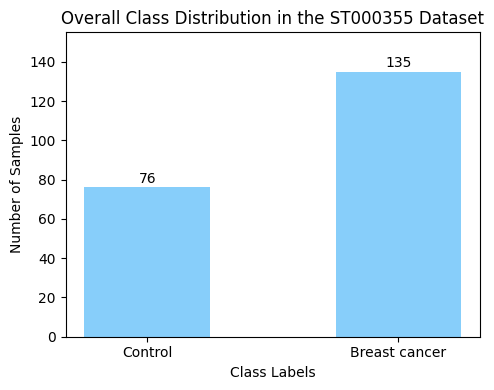

Class distribution:
Control: 76
Breast cancer: 135


In [6]:
# =========================
# Figure: Class Distribution of ST000355 Dataset
# Revised version
# =========================
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = resolve_data_path("ST000355_MERGED_log10_MinImputed.csv")

hormone_columns = [
    "11-Dehydrocorticosterone_POS",
    "11-deoxycortisol_POS",
    "11-ketotestosterone_POS",
    "17a-OH-progesterone_POS",
    "Androstenedione_POS",
    "Corticosterone_POS",
    "Cortisol_POS",
    "Cortisone_POS",
    "Estradiol_POS",
    "Pregnenolone_POS",
    "Testosterone_POS",
    "DHEA-sulfate_NEG",
]

df = pd.read_csv(DATA_PATH)

if "Factor_Diagnosis" not in df.columns:
    raise ValueError("Missing 'Factor_Diagnosis' column in CSV.")

fg = df["Factor_Diagnosis"]
fg_norm = fg.astype(str).str.strip().str.lower()
y = fg_norm.map({
    "control": 0,
    "breast cancer": 1
})

if y.isna().any():
    bad = df.loc[y.isna(), "Factor_Diagnosis"].unique()
    raise ValueError(f"Unmapped Factor_Diagnosis values: {bad}")

y = y.astype(int)

class_counts = y.value_counts().sort_index()

label_map = {
    0: "Control",
    1: "Breast cancer"
}
labels = [label_map.get(i, str(i)) for i in class_counts.index]
counts = class_counts.values

plt.figure(figsize=(5, 4))
bars = plt.bar(labels, counts, width=0.5, color="lightskyblue")

plt.title("Overall Class Distribution in the ST000355 Dataset")
plt.xlabel("Class Labels")
plt.ylabel("Number of Samples")
plt.ylim(0, max(counts) + 20)

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(count),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

print("Class distribution:")
for lbl, cnt in zip(labels, counts):
    print(f"{lbl}: {cnt}")

In [9]:
# =========================
# Full overall comparison table on ST000355
# Rebuild Accuracy / F1 / Precision / Recall from saved OOF predictions
# =========================

import os
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# -------------------------
# 1. Load AUC summary table
# -------------------------
final_df = pd.read_csv("Final_comparison_models.csv").copy()
final_df.columns = [str(c).strip() for c in final_df.columns]

final_df["Model"] = final_df["Model"].astype(str).str.strip()
final_df["mean_auc"] = pd.to_numeric(final_df["mean_auc"], errors="coerce")
final_df["std_auc"] = pd.to_numeric(final_df["std_auc"], errors="coerce")

# -------------------------
# 2. Rename models to thesis-friendly names
# -------------------------
rename_map = {
    "Hybrid_concat_LR_Curriculum_GAN": "Hybrid_Curriculum_cGAN",
    "Hybrid_concat_LR_Standard_GAN": "Hybrid_cGAN",
    "Hybrid_concat_LR_Curriculum": "Hybrid_Curriculum",
    "Baseline_SVM_Standard": "Baseline_SVM",
    "Baseline_LR_Standard": "Baseline_LR",
    "Baseline_LightGBM_Standard": "Baseline_LightGBM",
    "Hybrid_concat_LR_Curriculum_Smote": "Hybrid_Curriculum_SMOTE",
    "Hybrid_concat_LR_Standard_Smote": "Hybrid_SMOTE"
}
final_df["Model"] = final_df["Model"].replace(rename_map)

# -------------------------
# 3. Models to keep
# -------------------------
selected_models = [
    "Hybrid_Curriculum_cGAN",
    "Hybrid_cGAN",
    "Baseline_SVM",
    "Baseline_LR",
    "Hybrid_Curriculum",
    "Baseline_LightGBM"
]

final_df = final_df[final_df["Model"].isin(selected_models)].copy()

# -------------------------
# 4. Map thesis names back to raw filenames
# -------------------------
reverse_name_map = {
    "Hybrid_Curriculum_cGAN": "Hybrid_concat_LR_Curriculum_GAN",
    "Hybrid_cGAN": "Hybrid_concat_LR_Standard_GAN",
    "Hybrid_Curriculum": "Hybrid_concat_LR_Curriculum",
    "Baseline_SVM": "Baseline_SVM_Standard",
    "Baseline_LR": "Baseline_LR_Standard",
    "Baseline_LightGBM": "Baseline_LightGBM_Standard"
}

# -------------------------
# 5. Recompute OOF metrics
# -------------------------
metrics_rows = []

for thesis_name in selected_models:
    raw_name = reverse_name_map[thesis_name]
    oof_csv_path = os.path.join("oof_outputs", f"{raw_name}_oof_predictions.csv")

    if not os.path.exists(oof_csv_path):
        print(f"Warning: missing OOF file for {thesis_name}: {oof_csv_path}")
        continue

    oof_df = pd.read_csv(oof_csv_path)
    oof_df.columns = [str(c).strip() for c in oof_df.columns]

    # Try to detect prediction columns robustly
    y_true_col = None
    y_pred_col = None

    for c in oof_df.columns:
        lc = c.lower()
        if lc in ["y_true", "true", "label", "y"]:
            y_true_col = c
        if lc in ["y_pred", "pred", "prediction", "pred_label"]:
            y_pred_col = c

    if y_true_col is None or y_pred_col is None:
        raise ValueError(
            f"Could not detect y_true / y_pred columns in {oof_csv_path}. Found columns: {list(oof_df.columns)}"
        )

    y_true = oof_df[y_true_col].astype(int).values
    y_pred = oof_df[y_pred_col].astype(int).values

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)

    metrics_rows.append({
        "Model": thesis_name,
        "Accuracy": acc,
        "F1 Score": f1,
        "Precision": prec,
        "Recall": rec
    })

metrics_df = pd.DataFrame(metrics_rows)

# -------------------------
# 6. Merge AUC + OOF metrics
# -------------------------
section56_full_df = final_df.merge(metrics_df, on="Model", how="left")

# rebuild formatted auc text
section56_full_df["AUC-ROC"] = section56_full_df.apply(
    lambda r: f"{r['mean_auc']:.4f} ± {r['std_auc']:.4f}",
    axis=1
)

# sort by mean_auc descending
section56_full_df = section56_full_df.sort_values("mean_auc", ascending=False).reset_index(drop=True)

# final column order
section56_full_df = section56_full_df[
    ["Model", "AUC-ROC", "mean_auc", "std_auc", "Accuracy", "F1 Score", "Precision", "Recall"]
]

# save
section56_full_df.to_csv("section56_table_full_overall_st000355.csv", index=False)

display(section56_full_df)
print("Saved: section56_table_full_overall_st000355.csv")

,Model,AUC-ROC,mean_auc,std_auc,Accuracy,F1 Score,Precision,Recall
0,Hybrid_Curriculum_cGAN,0.9896 ± 0.0195,0.989630,0.019530,0.976303,0.981413,0.985075,0.977778
1,Baseline_LR,0.9881 ± 0.0237,0.988148,0.023704,0.976303,0.981818,0.964286,1.000000
2,Baseline_SVM,0.9881 ± 0.0237,0.988148,0.023704,0.976303,0.981413,0.985075,0.977778
3,Hybrid_cGAN,0.9867 ± 0.0242,0.986698,0.024237,0.985782,0.988848,0.992537,0.985185
4,Hybrid_Curriculum,0.9853 ± 0.0237,0.985278,0.023661,0.966825,0.973978,0.977612,0.970370
5,Baseline_LightGBM,0.9807 ± 0.0254,0.980741,0.025393,0.971564,0.977941,0.970803,0.985185


Saved: section56_table_full_overall_st000355.csv


['y_true', 'y_prob', 'y_pred']


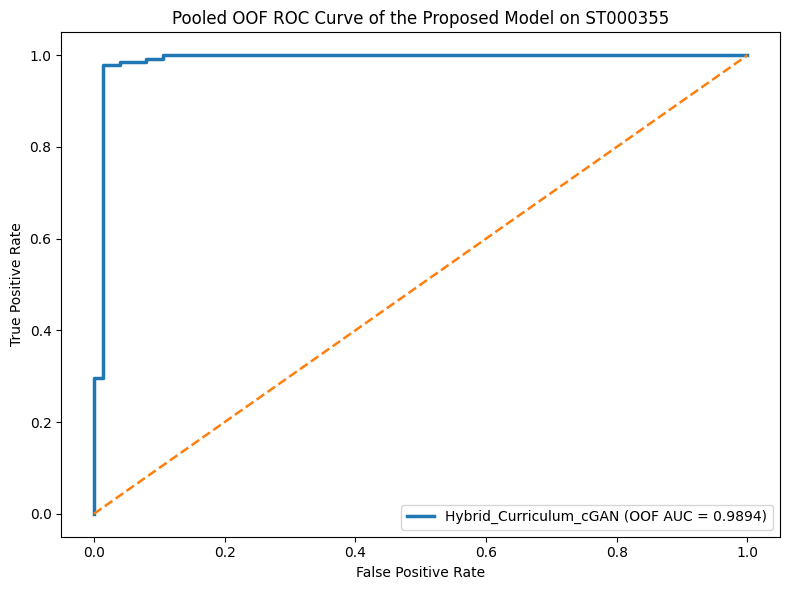

Saved: ST000355_proposed_model_roc_curve.png


In [11]:
# =========================
# ROC curve of the proposed model on ST000355
# =========================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

oof_path = "oof_outputs/Hybrid_concat_LR_Curriculum_GAN_oof_predictions.csv"
oof_df = pd.read_csv(oof_path)

print(oof_df.columns.tolist())

y_true = oof_df["y_true"].astype(int).values
y_prob = oof_df["y_prob"].astype(float).values

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_val = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2.5, label=f"Hybrid_Curriculum_cGAN (OOF AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.8)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Pooled OOF ROC Curve of the Proposed Model on ST000355")
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()

plt.savefig("ST000355_proposed_model_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: ST000355_proposed_model_roc_curve.png")